# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np

# Assuming the tfmd package is installed or in the python path
from tfmd.core import TFMD, TFMDOptions
from tfmd.signal_generator import generate_signal
from tfmd.visualization import plot_decomposition, plot_pipeline_steps

# This line is for notebook environments to display plots inline
%matplotlib inline

# 2. Generate a Synthetic Signal

In [3]:
fs = 1000  # Sampling frequency
case_idx = 4  # Chirp and AM Tone

data = generate_signal(case_idx, fs=fs)
signal = data['clean']
t = data['t']

print(f"Generated signal: '{data['name']}'")
print(f"Number of ground truth components: {data['num_gt']}")

Generated signal: 'Chirp and AM Tone'
Number of ground truth components: 2


# 3. Decompose the Signal with Default Parameters

In [4]:
# Use default options
default_options = TFMDOptions()
decomposer = TFMD(options=default_options)

# Decompose the signal
modes, reconstructed = decomposer.decompose(signal, fs)

TFMD: Extracted 1 modes from signal (N=1000, fs=1000 Hz)


# 4. Visualize the Initial Result


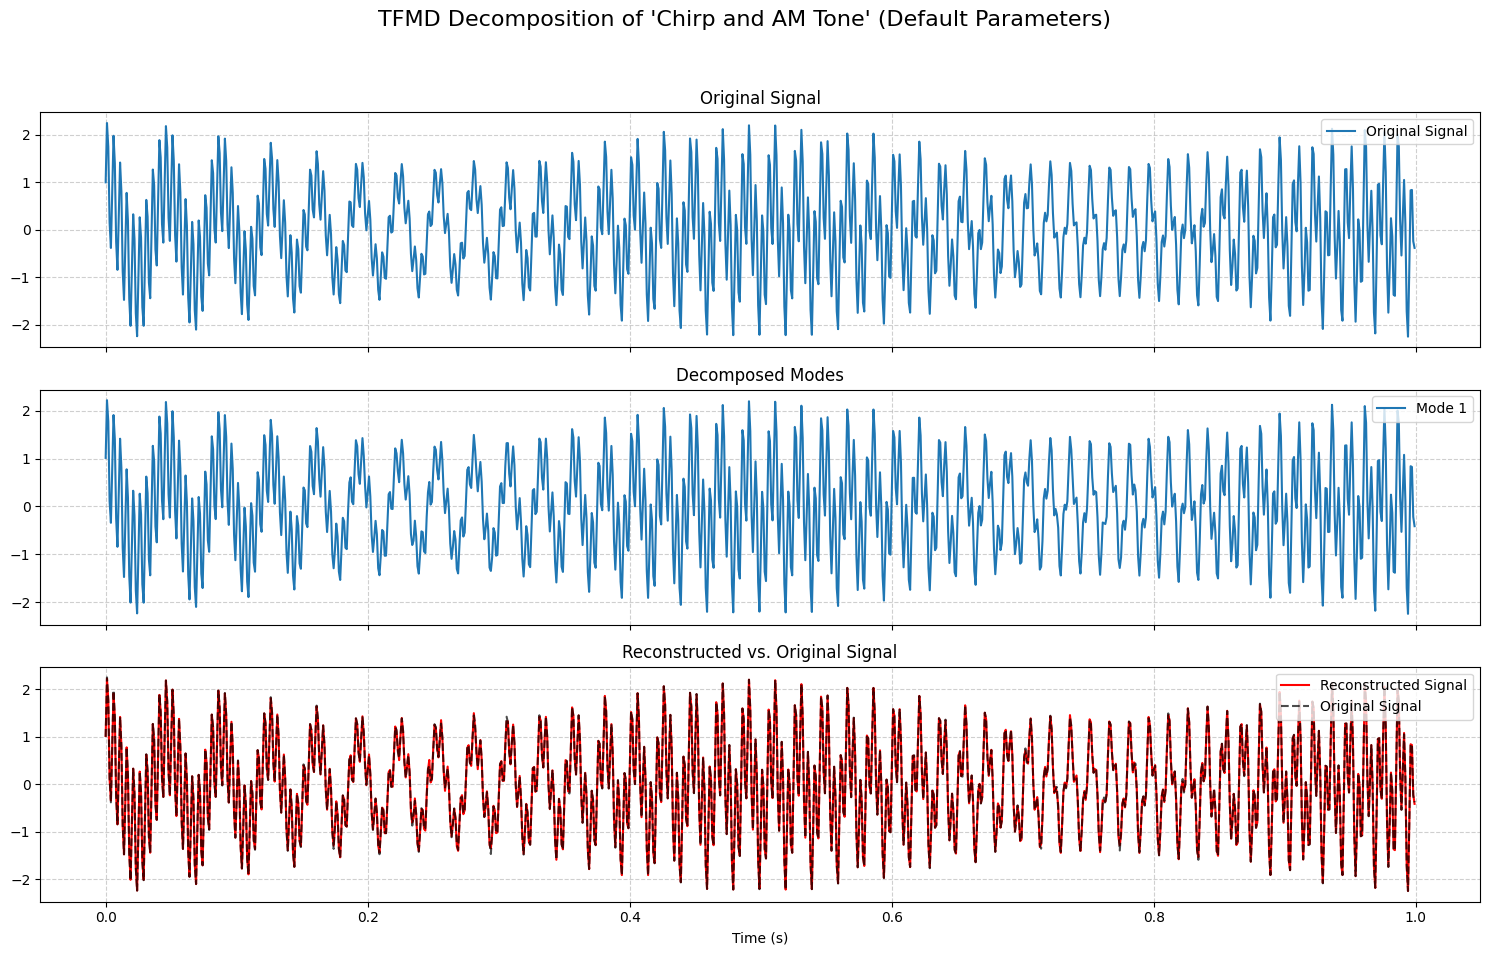

Relative L2 Error is 0.020109294206036004


In [5]:
plot_decomposition(
    original_signal=signal,
    t=t,
    modes=modes,
    reconstructed_signal=reconstructed,
    title=f"TFMD Decomposition of '{data['name']}' (Default Parameters)",
    env='notebook'
)
error = np.linalg.norm(signal - reconstructed) / np.linalg.norm(signal)
print(f"Relative L2 Error is {error}")

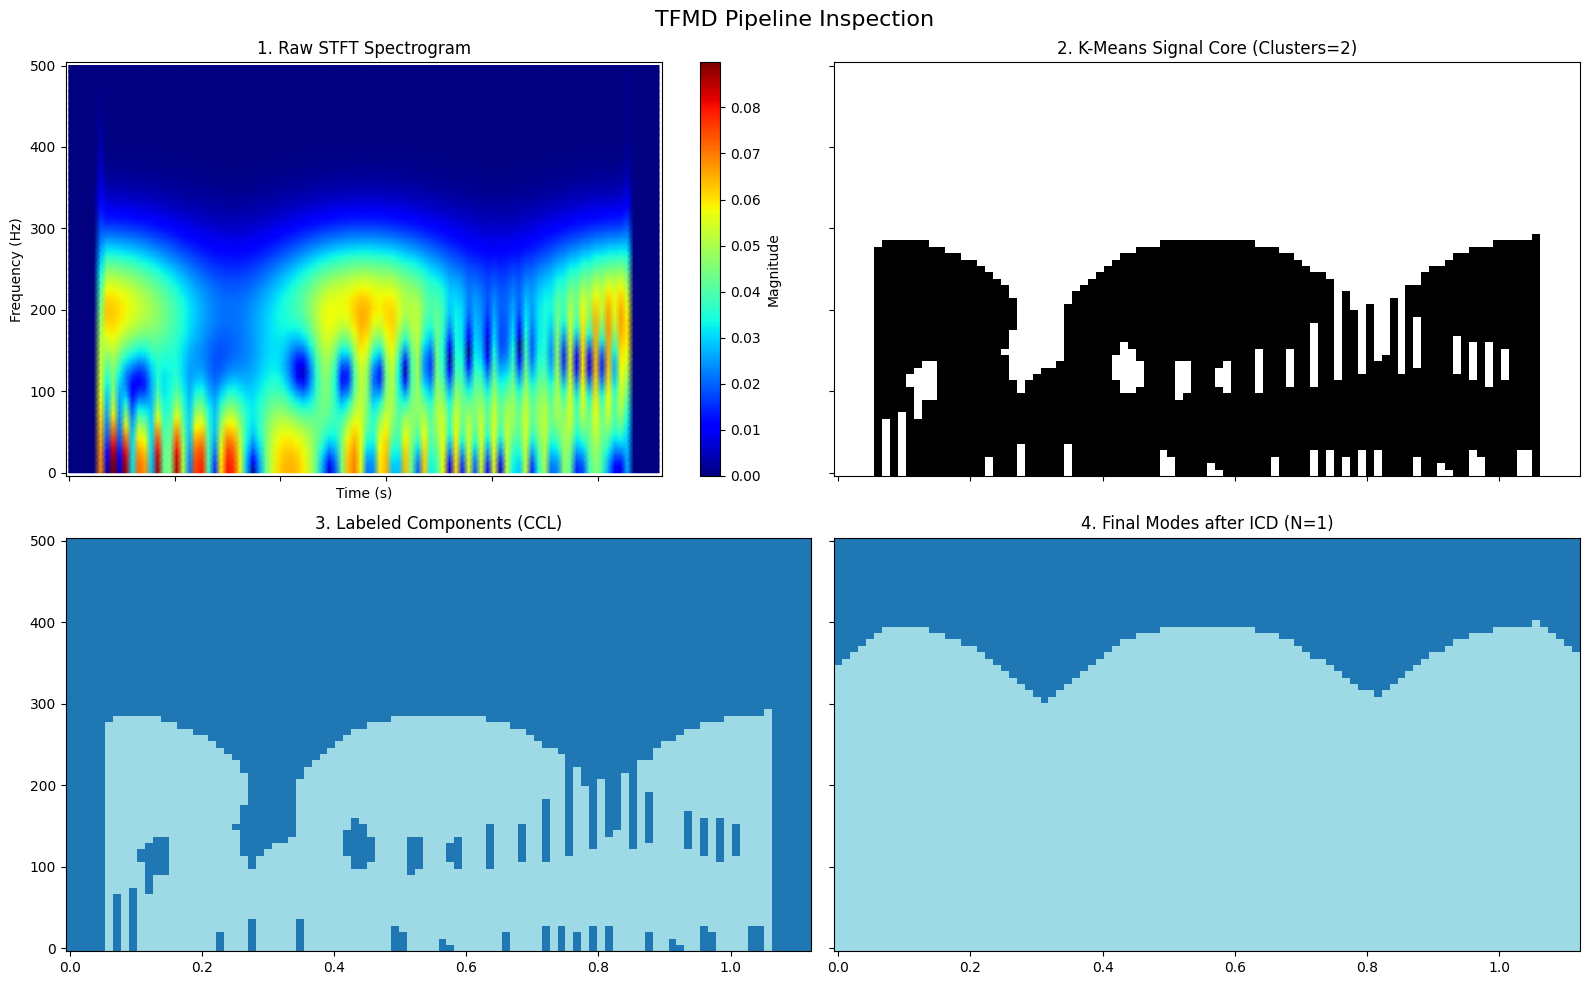

In [6]:
plot_pipeline_steps(decomposer, fs) 

# 5. Analyze the Result and Tune Parameters

The plot from the previous cell shows that the algorithm found only one mode. This is a mode merging failure, where the two distinct components were not separated. The original paper's README.md provides a hint for this situation: "When to Adjust: Closely spaced frequencies: Reduce alpha to 1.5-2.0".

In [7]:
# Tune parameters for better frequency resolution
tuned_options = TFMDOptions(
    alpha=2.0  # Reduced from 2.5 to improve frequency resolution
)
tuned_decomposer = TFMD(options=tuned_options)

# Decompose the signal again with the new options
tuned_modes, tuned_reconstructed = tuned_decomposer.decompose(signal, fs)

TFMD: Extracted 3 modes from signal (N=1000, fs=1000 Hz)


# 6. Visualize the Tuned Result

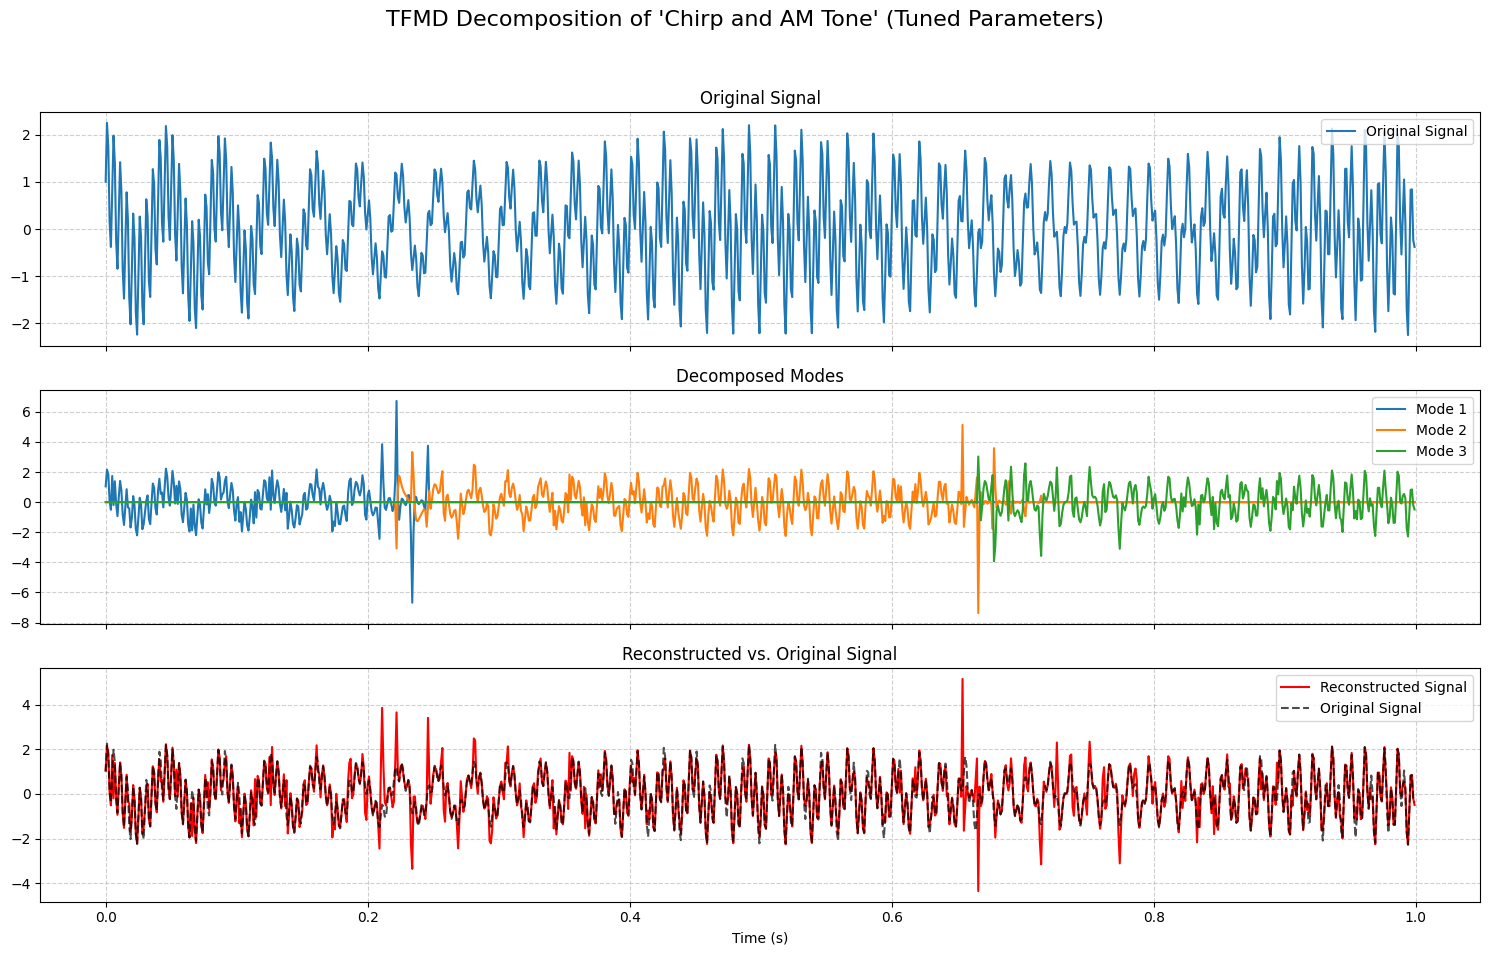

Relative L2 Error is 0.52881204232483


In [8]:
plot_decomposition(
    original_signal=signal,
    t=t,
    modes=tuned_modes,
    reconstructed_signal=tuned_reconstructed,
    title=f"TFMD Decomposition of '{data['name']}' (Tuned Parameters)",
    env='notebook'
)
error_tuned = np.linalg.norm(signal - tuned_reconstructed) / np.linalg.norm(signal)
print(f"Relative L2 Error is {error_tuned}")

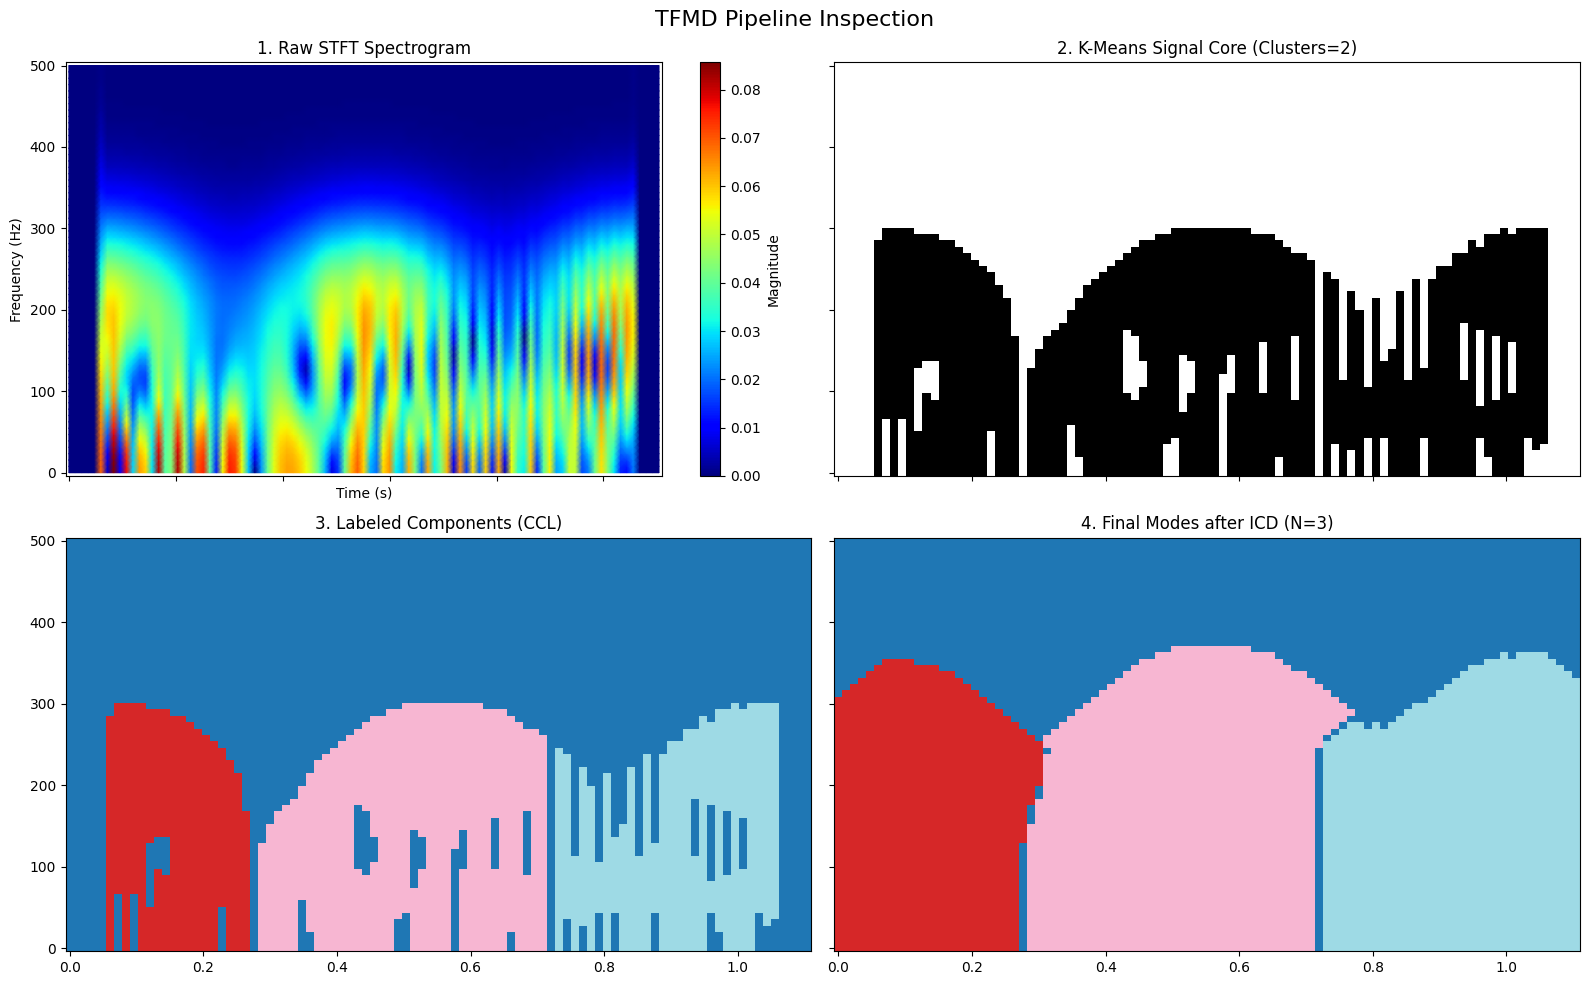

In [9]:
plot_pipeline_steps(tuned_decomposer, fs) 

In [11]:
tuned_options_2 = TFMDOptions(
    alpha=2.1  # Reduced from 2.5 to improve frequency resolution
)
tuned_decomposer_2 = TFMD(options=tuned_options_2)

# Decompose the signal again with the new options
tuned_modes_2, tuned_reconstructed_2 = tuned_decomposer_2.decompose(signal, fs)

TFMD: Extracted 2 modes from signal (N=1000, fs=1000 Hz)


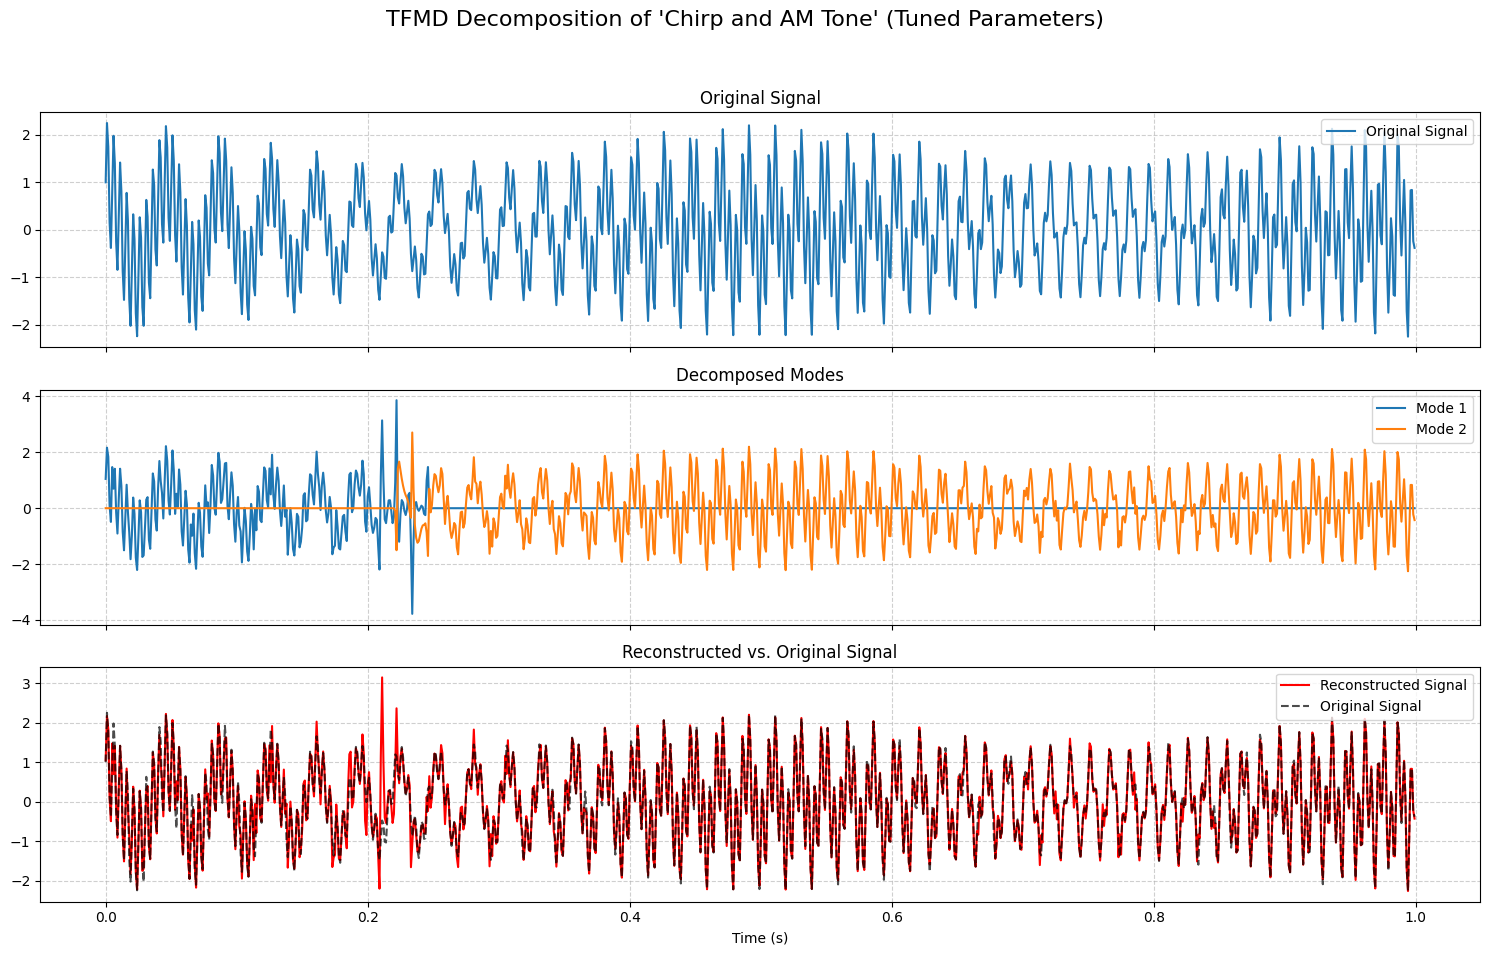

Relative L2 Error is 0.24400912359662336


In [12]:
plot_decomposition(
    original_signal=signal,
    t=t,
    modes=tuned_modes_2,
    reconstructed_signal=tuned_reconstructed_2,
    title=f"TFMD Decomposition of '{data['name']}' (Tuned Parameters)",
    env='notebook'
)
error_tuned_2 = np.linalg.norm(signal - tuned_reconstructed_2) / np.linalg.norm(signal)
print(f"Relative L2 Error is {error_tuned_2}")

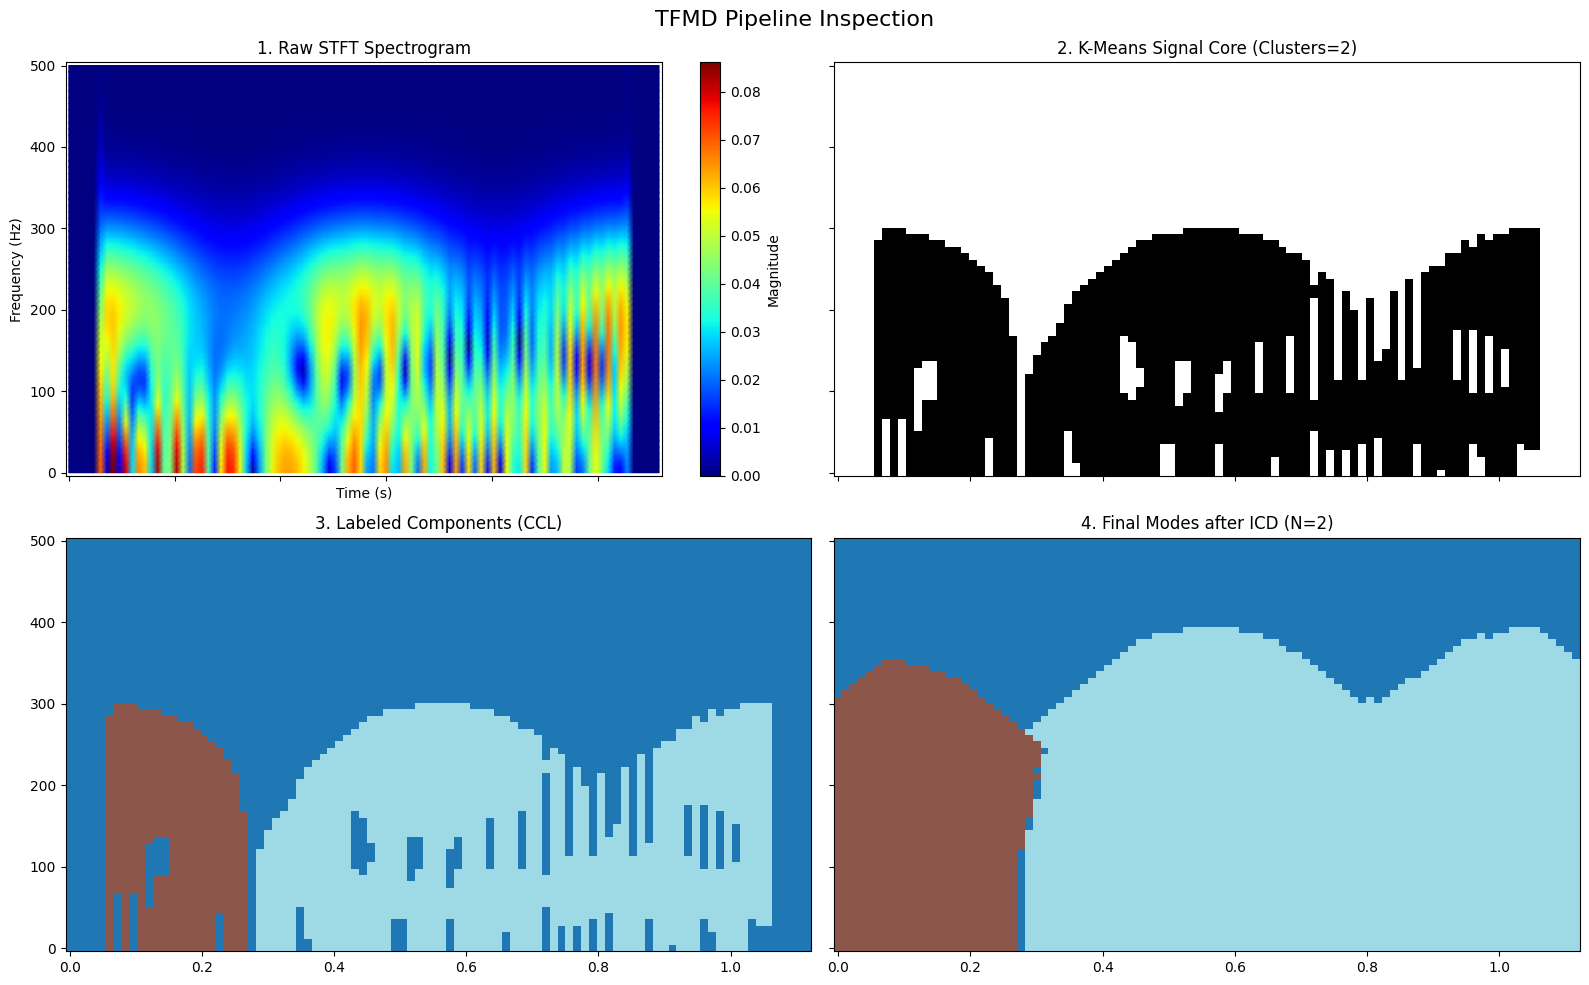

In [13]:
plot_pipeline_steps(tuned_decomposer_2, fs) 